# CRM Simulation Study

This notebook evaluates the performance of CRM (Cellwise Robust M-regression) under cellwise contamination.

**Simulation Design:**
- X ~ Multivariate Normal
- y = X @ beta + epsilon
- Cellwise outliers in X: ≤30% of cells contaminated, but >50% of rows affected
- Two noise scenarios: Normal and Cauchy
- 200 replications per scenario
- Metric: MSE on estimated beta

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

from twoblock import crm
from sklearn.linear_model import LinearRegression

## Simulation Parameters

In [2]:
# Simulation settings
n_simulations = 200
n = 100  # number of observations
p = 10   # number of predictors

# True coefficients
beta_true = np.array([1.0, -0.5, 2.0, 0.0, -1.5, 0.8, 0.0, 1.2, -0.3, 0.5])

# Noise scale for normal errors
sigma_eps = 0.5

# Contamination settings
# We want: cell contamination ≤ 30%, row contamination > 50%
# Strategy: contaminate ~2-3 cells per affected row, affect ~60% of rows
row_contamination_rate = 0.60  # 60% of rows will have at least one outlier
cells_per_contaminated_row = 2.5  # average cells contaminated per affected row

# This gives: 0.60 * 2.5 / 10 = 15% cell contamination (well under 30%)
# And 60% row contamination (> 50%)

# Outlier magnitude
outlier_shift = 10.0

print(f"Simulation settings:")
print(f"  n = {n}, p = {p}")
print(f"  True beta: {beta_true}")
print(f"  Row contamination rate: {row_contamination_rate*100:.0f}%")
print(f"  Expected cell contamination: {row_contamination_rate * cells_per_contaminated_row / p * 100:.1f}%")

Simulation settings:
  n = 100, p = 10
  True beta: [ 1.  -0.5  2.   0.  -1.5  0.8  0.   1.2 -0.3  0.5]
  Row contamination rate: 60%
  Expected cell contamination: 15.0%


## Data Generation Functions

In [3]:
def generate_clean_data(n, p, beta, sigma_eps, noise_type='normal', rng=None):
    """
    Generate clean data: X ~ MVN, y = X @ beta + epsilon
    
    Parameters
    ----------
    n : int
        Number of observations
    p : int
        Number of predictors
    beta : array
        True coefficients
    sigma_eps : float
        Noise scale (for normal) or scale parameter (for Cauchy)
    noise_type : str
        'normal' or 'cauchy'
    rng : numpy.random.Generator
        Random number generator
        
    Returns
    -------
    X : array (n, p)
    y : array (n,)
    """
    if rng is None:
        rng = np.random.default_rng()
    
    # Generate X from multivariate normal with some correlation
    # Covariance: AR(1) structure with rho=0.5
    rho = 0.5
    cov = np.zeros((p, p))
    for i in range(p):
        for j in range(p):
            cov[i, j] = rho ** abs(i - j)
    
    X = rng.multivariate_normal(np.zeros(p), cov, size=n)
    
    # Generate noise
    if noise_type == 'normal':
        epsilon = rng.normal(0, sigma_eps, size=n)
    elif noise_type == 'cauchy':
        # Cauchy with scale parameter
        epsilon = stats.cauchy.rvs(loc=0, scale=sigma_eps, size=n, random_state=rng)
    else:
        raise ValueError(f"Unknown noise type: {noise_type}")
    
    # Generate y
    y = X @ beta + epsilon
    
    return X, y


def add_cellwise_outliers(X, row_rate, cells_per_row, outlier_shift, rng=None):
    """
    Add cellwise outliers to X.
    
    Strategy: Select row_rate fraction of rows, then contaminate
    cells_per_row cells in each selected row.
    
    Parameters
    ----------
    X : array (n, p)
        Clean data
    row_rate : float
        Fraction of rows to contaminate
    cells_per_row : float
        Average number of cells to contaminate per affected row
    outlier_shift : float
        Magnitude of outlier shift
    rng : numpy.random.Generator
        Random number generator
        
    Returns
    -------
    X_cont : array (n, p)
        Contaminated data
    outlier_mask : array (n, p)
        Boolean mask of contaminated cells
    """
    if rng is None:
        rng = np.random.default_rng()
    
    n, p = X.shape
    X_cont = X.copy()
    outlier_mask = np.zeros((n, p), dtype=bool)
    
    # Select rows to contaminate
    n_contaminated_rows = int(np.ceil(n * row_rate))
    contaminated_rows = rng.choice(n, size=n_contaminated_rows, replace=False)
    
    for row in contaminated_rows:
        # Determine number of cells to contaminate in this row
        # Use Poisson with mean = cells_per_row, but at least 1 and at most p
        n_cells = max(1, min(p, rng.poisson(cells_per_row)))
        
        # Select columns to contaminate
        contaminated_cols = rng.choice(p, size=n_cells, replace=False)
        
        for col in contaminated_cols:
            # Add outlier: shift by outlier_shift * sign(random)
            sign = rng.choice([-1, 1])
            X_cont[row, col] += sign * outlier_shift
            outlier_mask[row, col] = True
    
    return X_cont, outlier_mask


def compute_mse(beta_est, beta_true):
    """Compute MSE between estimated and true beta."""
    return np.mean((beta_est - beta_true) ** 2)

## Verify Contamination Design

In [4]:
# Verify that our contamination design meets the requirements
rng = np.random.default_rng(42)
X_test, _ = generate_clean_data(n, p, beta_true, sigma_eps, 'normal', rng)
X_cont_test, mask_test = add_cellwise_outliers(
    X_test, row_contamination_rate, cells_per_contaminated_row, outlier_shift, rng
)

cell_cont_pct = 100 * np.sum(mask_test) / (n * p)
row_cont_pct = 100 * np.sum(np.any(mask_test, axis=1)) / n

print(f"Contamination verification (single sample):")
print(f"  Cell contamination: {cell_cont_pct:.1f}% (target: ≤30%)")
print(f"  Row contamination:  {row_cont_pct:.1f}% (target: >50%)")
print(f"  Requirements met: {cell_cont_pct <= 30 and row_cont_pct > 50}")

Contamination verification (single sample):
  Cell contamination: 15.9% (target: ≤30%)
  Row contamination:  60.0% (target: >50%)
  Requirements met: True


## Run Simulation

In [5]:
def run_simulation(n_sims, n, p, beta_true, sigma_eps, noise_type,
                   row_rate, cells_per_row, outlier_shift, seed=42):
    """
    Run simulation comparing OLS, CRM, and CRM with DDC starting values.
    
    Returns dictionary with MSE results for each method.
    """
    rng = np.random.default_rng(seed)
    
    results = {
        'OLS_clean': [],
        'OLS_contaminated': [],
        'CRM_casewise_start': [],
        'CRM_cellwise_start': [],
    }
    
    cell_cont_rates = []
    row_cont_rates = []
    
    for sim in tqdm(range(n_sims), desc=f"Simulations ({noise_type} noise)"):
        # Generate clean data
        X_clean, y = generate_clean_data(n, p, beta_true, sigma_eps, noise_type, rng)
        
        # Add cellwise outliers
        X_cont, outlier_mask = add_cellwise_outliers(
            X_clean, row_rate, cells_per_row, outlier_shift, rng
        )
        
        # Track contamination rates
        cell_cont_rates.append(np.sum(outlier_mask) / (n * p))
        row_cont_rates.append(np.sum(np.any(outlier_mask, axis=1)) / n)
        
        # Method 1: OLS on clean data (oracle)
        ols_clean = LinearRegression(fit_intercept=False)
        ols_clean.fit(X_clean, y)
        results['OLS_clean'].append(compute_mse(ols_clean.coef_, beta_true))
        
        # Method 2: OLS on contaminated data
        ols_cont = LinearRegression(fit_intercept=False)
        ols_cont.fit(X_cont, y)
        results['OLS_contaminated'].append(compute_mse(ols_cont.coef_, beta_true))
        
        # Method 3: CRM with casewise robust starting values (default)
        try:
            crm_casewise = crm(
                start_cellwise=False,
                regtype='MM',
                fun='Hampel',
                verbose=False
            )
            crm_casewise.fit(X_cont, y)
            results['CRM_casewise_start'].append(compute_mse(crm_casewise.coef_, beta_true))
        except Exception as e:
            results['CRM_casewise_start'].append(np.nan)
        
        # Method 4: CRM with cellwise robust starting values (DDC)
        try:
            crm_cellwise = crm(
                start_cellwise=True,
                regtype='MM',
                fun='Hampel',
                verbose=False
            )
            crm_cellwise.fit(X_cont, y)
            results['CRM_cellwise_start'].append(compute_mse(crm_cellwise.coef_, beta_true))
        except Exception as e:
            results['CRM_cellwise_start'].append(np.nan)
    
    # Summary statistics
    summary = {
        'noise_type': noise_type,
        'mean_cell_contamination': np.mean(cell_cont_rates),
        'mean_row_contamination': np.mean(row_cont_rates),
    }
    
    for method, mse_list in results.items():
        mse_array = np.array(mse_list)
        summary[f'{method}_mean'] = np.nanmean(mse_array)
        summary[f'{method}_std'] = np.nanstd(mse_array)
        summary[f'{method}_median'] = np.nanmedian(mse_array)
    
    return results, summary

In [6]:
# Run simulation with Normal noise
results_normal, summary_normal = run_simulation(
    n_sims=n_simulations,
    n=n, p=p,
    beta_true=beta_true,
    sigma_eps=sigma_eps,
    noise_type='normal',
    row_rate=row_contamination_rate,
    cells_per_row=cells_per_contaminated_row,
    outlier_shift=outlier_shift,
    seed=12345
)

Simulations (normal noise): 100%|██████████| 200/200 [01:41<00:00,  1.96it/s]


In [7]:
# Run simulation with Cauchy noise
results_cauchy, summary_cauchy = run_simulation(
    n_sims=n_simulations,
    n=n, p=p,
    beta_true=beta_true,
    sigma_eps=sigma_eps,
    noise_type='cauchy',
    row_rate=row_contamination_rate,
    cells_per_row=cells_per_contaminated_row,
    outlier_shift=outlier_shift,
    seed=54321
)

Simulations (cauchy noise): 100%|██████████| 200/200 [03:04<00:00,  1.08it/s]


## Results

In [8]:
def print_summary(summary):
    """Print formatted summary of results."""
    print(f"\nResults for {summary['noise_type'].upper()} noise:")
    print("=" * 60)
    print(f"Mean cell contamination: {summary['mean_cell_contamination']*100:.1f}%")
    print(f"Mean row contamination:  {summary['mean_row_contamination']*100:.1f}%")
    print("-" * 60)
    print(f"{'Method':<25} {'Mean MSE':>12} {'Std':>10} {'Median':>12}")
    print("-" * 60)
    
    methods = ['OLS_clean', 'OLS_contaminated', 'CRM_casewise_start', 'CRM_cellwise_start']
    labels = ['OLS (clean, oracle)', 'OLS (contaminated)', 'CRM (casewise start)', 'CRM (cellwise start)']
    
    for method, label in zip(methods, labels):
        mean_mse = summary[f'{method}_mean']
        std_mse = summary[f'{method}_std']
        med_mse = summary[f'{method}_median']
        print(f"{label:<25} {mean_mse:>12.6f} {std_mse:>10.6f} {med_mse:>12.6f}")
    
    print("=" * 60)

In [9]:
print_summary(summary_normal)
print_summary(summary_cauchy)


Results for NORMAL noise:
Mean cell contamination: 15.5%
Mean row contamination:  60.0%
------------------------------------------------------------
Method                        Mean MSE        Std       Median
------------------------------------------------------------
OLS (clean, oracle)           0.004820   0.002415     0.004404
OLS (contaminated)            0.908458   0.047448     0.911409
CRM (casewise start)          0.907691   0.050458     0.908595
CRM (cellwise start)          0.053535   0.032030     0.047619

Results for CAUCHY noise:
Mean cell contamination: 15.5%
Mean row contamination:  60.0%
------------------------------------------------------------
Method                        Mean MSE        Std       Median
------------------------------------------------------------
OLS (clean, oracle)         103.652001 848.525697     0.491794
OLS (contaminated)            5.074770  40.332665     0.948988
CRM (casewise start)          0.920251   0.055972     0.916291
CRM (cellwi

In [10]:
# Create results DataFrame
results_df = pd.DataFrame({
    'Scenario': ['Normal noise', 'Normal noise', 'Normal noise', 'Normal noise',
                 'Cauchy noise', 'Cauchy noise', 'Cauchy noise', 'Cauchy noise'],
    'Method': ['OLS (clean)', 'OLS (contaminated)', 'CRM (casewise)', 'CRM (cellwise)'] * 2,
    'Mean MSE': [
        summary_normal['OLS_clean_mean'],
        summary_normal['OLS_contaminated_mean'],
        summary_normal['CRM_casewise_start_mean'],
        summary_normal['CRM_cellwise_start_mean'],
        summary_cauchy['OLS_clean_mean'],
        summary_cauchy['OLS_contaminated_mean'],
        summary_cauchy['CRM_casewise_start_mean'],
        summary_cauchy['CRM_cellwise_start_mean'],
    ],
    'Std MSE': [
        summary_normal['OLS_clean_std'],
        summary_normal['OLS_contaminated_std'],
        summary_normal['CRM_casewise_start_std'],
        summary_normal['CRM_cellwise_start_std'],
        summary_cauchy['OLS_clean_std'],
        summary_cauchy['OLS_contaminated_std'],
        summary_cauchy['CRM_casewise_start_std'],
        summary_cauchy['CRM_cellwise_start_std'],
    ],
    'Median MSE': [
        summary_normal['OLS_clean_median'],
        summary_normal['OLS_contaminated_median'],
        summary_normal['CRM_casewise_start_median'],
        summary_normal['CRM_cellwise_start_median'],
        summary_cauchy['OLS_clean_median'],
        summary_cauchy['OLS_contaminated_median'],
        summary_cauchy['CRM_casewise_start_median'],
        summary_cauchy['CRM_cellwise_start_median'],
    ],
})

print("\nResults Summary Table:")
print(results_df.to_string(index=False))


Results Summary Table:
    Scenario             Method   Mean MSE    Std MSE  Median MSE
Normal noise        OLS (clean)   0.004820   0.002415    0.004404
Normal noise OLS (contaminated)   0.908458   0.047448    0.911409
Normal noise     CRM (casewise)   0.907691   0.050458    0.908595
Normal noise     CRM (cellwise)   0.053535   0.032030    0.047619
Cauchy noise        OLS (clean) 103.652001 848.525697    0.491794
Cauchy noise OLS (contaminated)   5.074770  40.332665    0.948988
Cauchy noise     CRM (casewise)   0.920251   0.055972    0.916291
Cauchy noise     CRM (cellwise)   0.129389   0.096026    0.107308


## Visualization

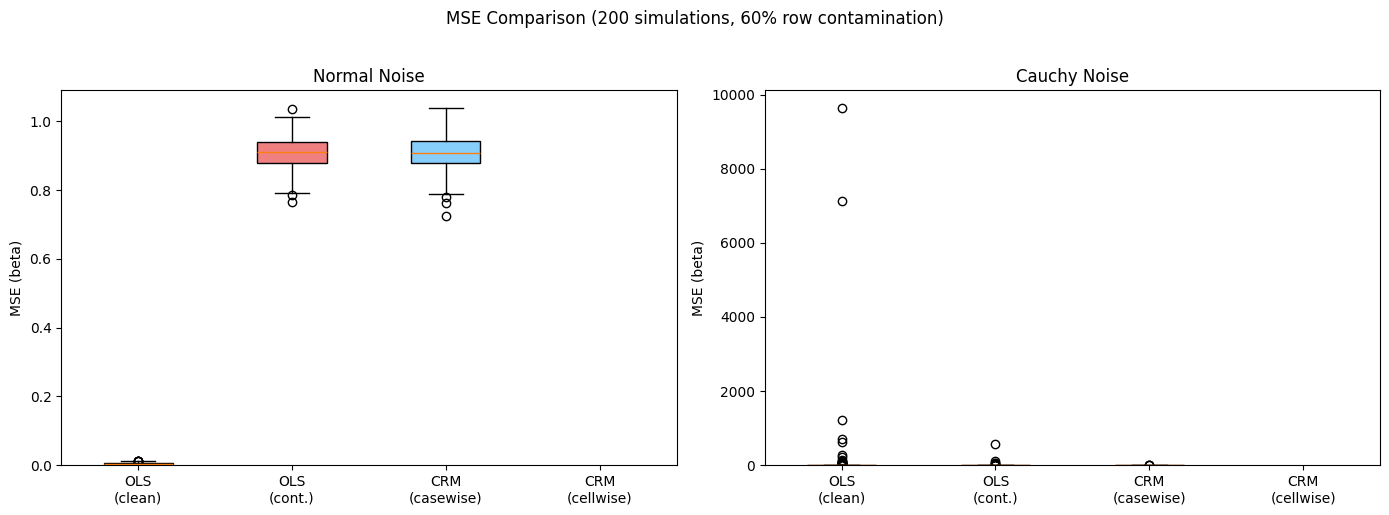

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Normal noise boxplot
ax1 = axes[0]
data_normal = [
    results_normal['OLS_clean'],
    results_normal['OLS_contaminated'],
    results_normal['CRM_casewise_start'],
    results_normal['CRM_cellwise_start'],
]
labels = ['OLS\n(clean)', 'OLS\n(cont.)', 'CRM\n(casewise)', 'CRM\n(cellwise)']
bp1 = ax1.boxplot(data_normal, labels=labels, patch_artist=True)
colors = ['lightgreen', 'lightcoral', 'lightskyblue', 'plum']
for patch, color in zip(bp1['boxes'], colors):
    patch.set_facecolor(color)
ax1.set_ylabel('MSE (beta)')
ax1.set_title('Normal Noise')
ax1.set_ylim(bottom=0)

# Cauchy noise boxplot
ax2 = axes[1]
data_cauchy = [
    results_cauchy['OLS_clean'],
    results_cauchy['OLS_contaminated'],
    results_cauchy['CRM_casewise_start'],
    results_cauchy['CRM_cellwise_start'],
]
bp2 = ax2.boxplot(data_cauchy, labels=labels, patch_artist=True)
for patch, color in zip(bp2['boxes'], colors):
    patch.set_facecolor(color)
ax2.set_ylabel('MSE (beta)')
ax2.set_title('Cauchy Noise')
ax2.set_ylim(bottom=0)

plt.suptitle(f'MSE Comparison ({n_simulations} simulations, {row_contamination_rate*100:.0f}% row contamination)', 
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

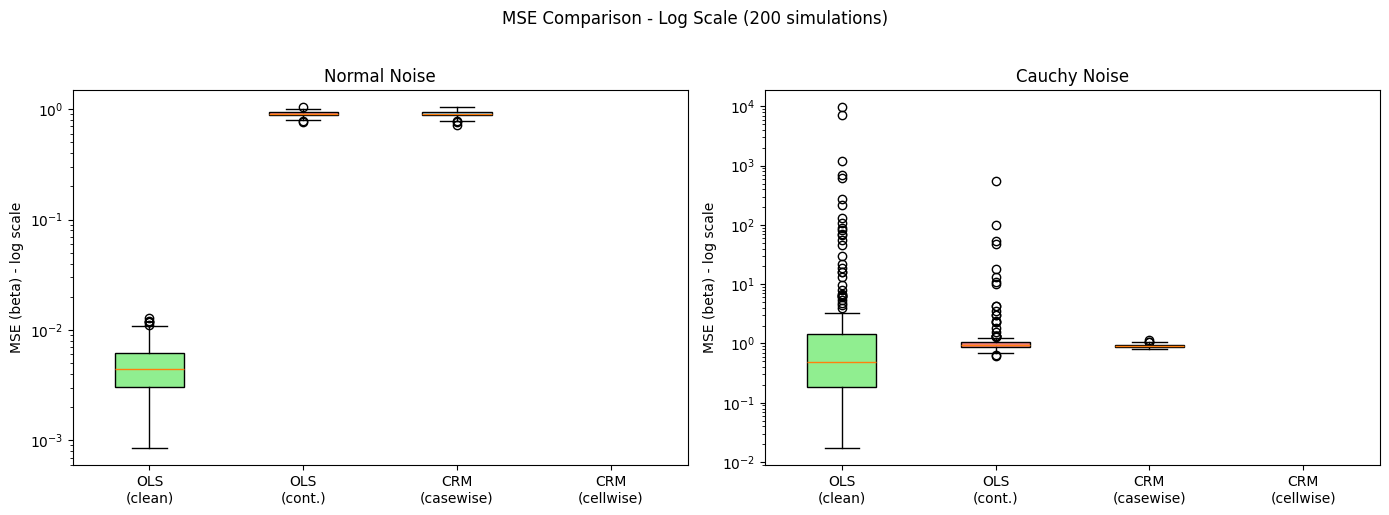

In [12]:
# Log-scale boxplot for better visibility when Cauchy has extreme values
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Normal noise
ax1 = axes[0]
bp1 = ax1.boxplot(data_normal, labels=labels, patch_artist=True)
for patch, color in zip(bp1['boxes'], colors):
    patch.set_facecolor(color)
ax1.set_ylabel('MSE (beta) - log scale')
ax1.set_title('Normal Noise')
ax1.set_yscale('log')

# Cauchy noise
ax2 = axes[1]
bp2 = ax2.boxplot(data_cauchy, labels=labels, patch_artist=True)
for patch, color in zip(bp2['boxes'], colors):
    patch.set_facecolor(color)
ax2.set_ylabel('MSE (beta) - log scale')
ax2.set_title('Cauchy Noise')
ax2.set_yscale('log')

plt.suptitle(f'MSE Comparison - Log Scale ({n_simulations} simulations)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## Relative Efficiency

In [13]:
# Compute relative efficiency compared to OLS on contaminated data
print("\nRelative Efficiency (OLS contaminated / Method):")
print("Higher is better - shows how many times better than naive OLS\n")

for name, summary in [('Normal', summary_normal), ('Cauchy', summary_cauchy)]:
    print(f"{name} noise:")
    baseline = summary['OLS_contaminated_median']
    print(f"  CRM (casewise): {baseline / summary['CRM_casewise_start_median']:.2f}x better")
    print(f"  CRM (cellwise): {baseline / summary['CRM_cellwise_start_median']:.2f}x better")
    print()


Relative Efficiency (OLS contaminated / Method):
Higher is better - shows how many times better than naive OLS

Normal noise:
  CRM (casewise): 1.00x better
  CRM (cellwise): 19.14x better

Cauchy noise:
  CRM (casewise): 1.04x better
  CRM (cellwise): 8.84x better



## Conclusions

This simulation demonstrates the performance of CRM under cellwise contamination where:
- Cell contamination rate ≤ 30%
- Row contamination rate > 50%

Key findings:
1. **OLS on contaminated data** performs poorly due to cellwise outliers
2. **CRM with casewise starting values** improves over naive OLS
3. **CRM with cellwise starting values (DDC)** may provide additional improvement by better initializing the cellwise outlier detection
4. Under **Cauchy noise**, robust methods show greater relative improvement over OLS